# Prva domača naloga pri predmetu ITAP

## Naloga 1 (20 točk): Učenje polinomskih modelov in regularizacija

V tej nalogi bomo raziskali, kako stopnja polinoma vpliva na prileganje polinomskega modela podatkom, ter spoznali regularizacijo Tihonova (angl. _ridge regression_) kot orodja za zmanjšanje nestabilnosti modelov.

**Za generiranje podatkov bomo uporabili polinom druge stopnje:** $y = 1 + 2x - x^2$ z dodanim šumom z Gaussovo porazdelitvijo $\mathcal{N}(0, \sigma), \sigma \approx 0{,}5$.

Podatke prebereš iz datoteke `dn1_e1.npz`, ki vsebuje 5 neodvisnih podatkovnih množic. Vsaka podatkovna množica v seznamu `datasets` je dvojica vektorjev `(x, y)`, kjer vektor `x` vsebuje vrednosti napovedne spremenljivke $x$, vektor `y` pa vrednosti ciljne spremenljivke $y$. Vsaka podatkovna množica vsebuje 7 primerov.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Naloži podatke
data = np.load('dn1_e1.npz')
## Seznam vseh podatkovnih množic
datasets = [(data[f'x{i}'], data[f'y{i}']) for i in range(1, 6)]
print(f'Število podatkovnih množic: {len(datasets)}, število primerov v vsaki: {len(datasets[0][0])}')


Število podatkovnih množic: 5, število primerov v vsaki: 7


### 1.a (2 točke): Polinomske značilke

Dopolni definicijo funkcijo `polinomske_znacilke(x, d)`, ki sprejme vektor `x` vrednosti napovedne spremenljivke $x$ in stopnjo značilk `d` ter vrne matriko dimenzij $n \times (d+1)$ s stolpci $[1, \boldsymbol{x}, \boldsymbol{x}^2, \ldots, \boldsymbol{x}^d]$ (imenujemo jo tudi Vandermondova matrika), kjer je $n$ število primerov.

In [2]:
def polinomske_znacilke(x: np.ndarray, d: int) -> np.ndarray:
    """Za podan vektor x in podano stopnjo d vrne Vandermondovo matriko [1, x, x^2, ..., x^d]."""
    matrika = np.zeros((len(x), d+1))

    for i in range(0, d+1):
        matrika[:, i] = x**i
        
    return matrika

In [3]:
# Preverjanje pravilnosti
x_test = np.array([0.0, 1.0, 2.0])
X_test = polinomske_znacilke(x_test, 3)

assert X_test.shape == (3, 4), f'Napačna oblika: {X_test.shape}, pričakovana (3, 4)'
assert np.allclose(X_test[0], [1, 0, 0, 0]), f'Napačna vrednost za x=0: {X_test[0]}'
assert np.allclose(X_test[1], [1, 1, 1, 1]), f'Napačna vrednost za x=1: {X_test[1]}'
assert np.allclose(X_test[2], [1, 2, 4, 8]), f'Napačna vrednost za x=2: {X_test[2]}'

print('Matrika za x=[0,1,2], d=3:')
print(X_test)

Matrika za x=[0,1,2], d=3:
[[1. 0. 0. 0.]
 [1. 1. 1. 1.]
 [1. 2. 4. 8.]]


### 1.b (7 točk): Točnost in splošnost polinomskih modelov različnih stopenj

Za vsako od petih podatkovnih množic poišči koeficiente polinomov stopenj 1 do 6. Za vsako stopnjo:
- razdeli podatke na učno (5 primerov) in testno množico (2 primera);
- izračunaj povprečno kvadratno napako (MSE) dobljenega polinoma na učni in testni množici.

Koeficiente polinoma izračunaj po formuli $\hat{\boldsymbol{\beta}} = (X^T X)^{-1} X^T \boldsymbol{y}$.

**Odgovori na vprašanja**

> _[Kakšna je stopnja polinoma, ki se najbolje prilega (a) učnim in (b) testnim podatkom?]_
- (a) Stopnja polinom, ki se najbolj prilega učnim podatkom je stopnja 4.
- (b) Stopnja polinom, ki se najbolj prilega testnim podatkom je stopnja 2. 
> _[Kaj opažaš pri visokih stopnjah polinoma?]_

**Pri odgovorih na vprašanja v domači nalogi si pomagaj s tabelami in grafi.**

In [4]:
from sklearn.metrics import mean_squared_error

Dataset 0, Degree 1: Train error: 0.9418591506441792, Test error: 7.496727788507854
Dataset 0, Degree 2: Train error: 0.05460131297979508, Test error: 0.9035301681958823
Dataset 0, Degree 3: Train error: 0.00045923342890522083, Test error: 0.06322562123258373
Dataset 0, Degree 4: Train error: 5.009182007235872e-28, Test error: 0.016156971924344156
Dataset 0, Degree 5: Train error: 2.70483465522143, Test error: 4.700309885112269
Dataset 0, Degree 6: Train error: 4.187466617136576, Test error: 20.15086348631118
Dataset 1, Degree 1: Train error: 0.46821697306622695, Test error: 2.7956769706271833
Dataset 1, Degree 2: Train error: 0.06327382502013008, Test error: 0.854342591239021
Dataset 1, Degree 3: Train error: 0.055945017149024855, Test error: 2.4007502401964103
Dataset 1, Degree 4: Train error: 5.406508443425539e-15, Test error: 13490216.602599798
Dataset 1, Degree 5: Train error: 0.08253916200787009, Test error: 2402255.159512134
Dataset 1, Degree 6: Train error: 1.5635253117974, Tes

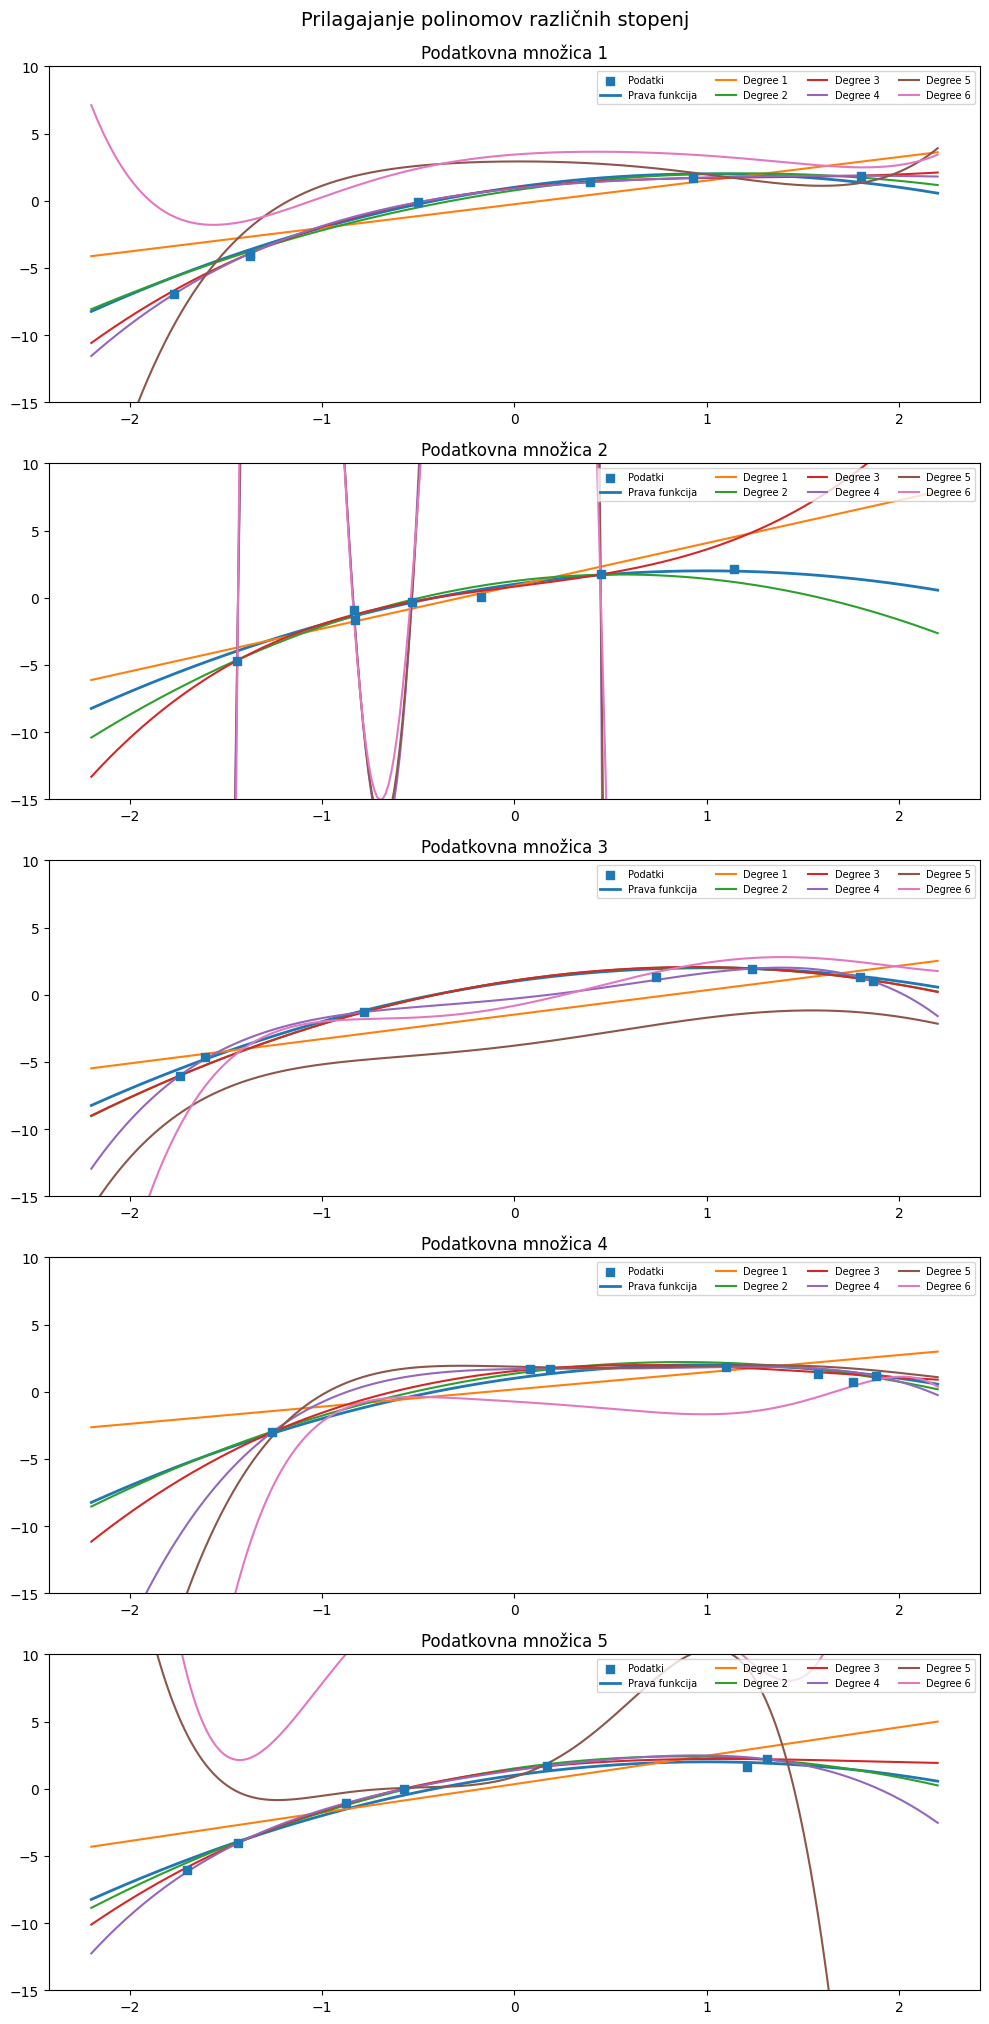

In [5]:
def najdi_koeficiente(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Izračuna koeficiente linearne regresije po formuli (X^T X)^{-1} X^T y."""
    return np.linalg.inv(X.T @ X) @ X.T @ y

def napovej(data: np.ndarray, beta: np.ndarray) -> np.ndarray:
    """Napove vrednost polinoma na podatke glede koeficiente beta."""
    return data @ beta

degrees = list(range(1, 7))

fig, axes = plt.subplots(5, 1, figsize=(10, 20))
x_plot = np.linspace(-2.2, 2.2, 300)

all_train_mse = []  # oblika (5 podatkovnih množic, 10 stopenj)
all_test_mse = []

for i, (x, y) in enumerate(datasets):
    # Razdelitev na učno in testno množico
    # Dopolni
    # Učna množica
    x_train = x[:5]
    y_train = y[:5]
    # Testna množica
    x_test = x[5:] 
    y_test = y[5:] 

    train_mses = []
    test_mses = []

    ax = axes[i]
    ax.scatter(x, y, zorder=5, label='Podatki', marker="s")
    x_true = np.linspace(-2.2, 2.2, 300)
    ax.plot(x_true, 1 + 2*x_true - x_true**2, label='Prava funkcija', linewidth=2)

    for d in degrees:
        # Dopolni: Izračunaj koeficiente polinoma, napovej y na učnih,
        # testnih in x_true podatkih ter napako na učnih in testnih podatkih
#Moja koda#
        # Vandermondove matrike
        X_train = polinomske_znacilke(x_train, d)
        X_test = polinomske_znacilke(x_test, d)
        X_true = polinomske_znacilke(x_true, d)

        beta = najdi_koeficiente(X_train, y_train)
        # Napoved
        y_train_pred = napovej(X_train, beta)
        y_test_pred = napovej(X_test, beta)
        pred_true = napovej(X_true, beta)
        # Napaka
        train_error = mean_squared_error(y_train, y_train_pred)
        test_error = mean_squared_error(y_test, y_test_pred)
#Moja koda#
        train_mses.append(train_error)
        test_mses.append(test_error)
        print(f"Dataset {i}, Degree {d}: Train error: {train_error}, Test error: {test_error}")
        ax.plot(x_true, pred_true, label=f'Degree {d}')


    all_train_mse.append(train_mses)
    all_test_mse.append(test_mses)

    ax.set_ylim(-15, 10)
    ax.set_title(f'Podatkovna množica {i+1}')
    ax.legend(loc='upper right', fontsize=7, ncol=4)

plt.tight_layout()
plt.suptitle('Prilagajanje polinomov različnih stopenj', y=1.01, fontsize=14)
plt.show()

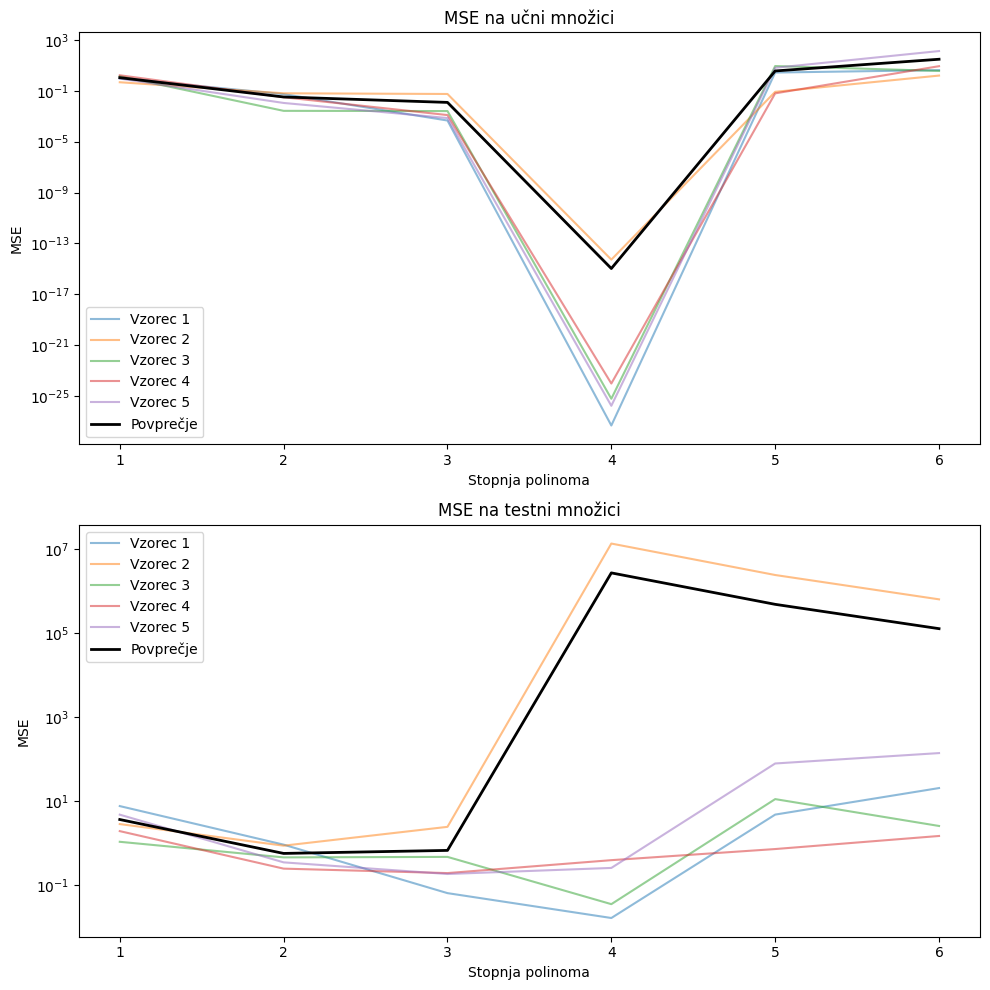

Najboljša stopnja polinoma po testnem MSE (povprečje): 2


In [6]:
# Graf MSE glede na stopnjo polinoma (povprečje čez 5 podatkovnih množic)
all_train_mse = np.array(all_train_mse)  # (5, 10)
all_test_mse = np.array(all_test_mse)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

for i in range(5):
    ax1.plot(degrees, all_train_mse[i], alpha=0.5, label=f'Vzorec {i+1}')
ax1.plot(degrees, all_train_mse.mean(axis=0), 'k-', linewidth=2, label='Povprečje')
ax1.set_xlabel('Stopnja polinoma')
ax1.set_ylabel('MSE')
ax1.set_title('MSE na učni množici')
ax1.legend()
ax1.set_yscale('log')

for i in range(5):
    ax2.plot(degrees, all_test_mse[i], alpha=0.5, label=f'Vzorec {i+1}')
ax2.plot(degrees, all_test_mse.mean(axis=0), 'k-', linewidth=2, label='Povprečje')
ax2.set_xlabel('Stopnja polinoma')
ax2.set_ylabel('MSE')
ax2.set_title('MSE na testni množici')
ax2.legend()
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

best_deg = degrees[int(np.argmin(all_test_mse.mean(axis=0)))]
print(f'Najboljša stopnja polinoma po testnem MSE (povprečje): {best_deg}')

**Odgovori na vprašanja**

> _[Vstavi sem svoja opažanja o najboljši stopnji polinoma.]_
- Najboljši stopnji polinoma sta 2 in 3. Za razliko od stopnje 4, imata nizko učno in testno napako (st 4 ima samo nizko učno). Če smo natančni je med njima za učne podatke najbolša st 3, za testne pa st 2. Izkaže se, da je pri teh stopnjah polinom dovolj preprost, da
se ne nauči šuma in s tem ne vodi do overfittinga.
> _[Ali se ta ujema s stopnjo 2 polinoma s katerim smo generirali podatke?]_
- Da, se ujema.
> _[Kaj se zgodi pri polinomih visokih stopenj, npr. $d=4,5,6$?]_
- Stopnja 4: tu imamo znake overfittinga. Učna napak je zelo nizka, ampak ko modelu
podamo nove testne podatke pa napaka zelo naraste.
- Stopnja 5 in 6: pri obeh stopnjah je tako učna kot testna napaka velika. Problem je
v tem, da imamo 5 učnih primerov, ampak polinom pa ima 6 oz. 7 parametrov. Posledično
pride do numerične nestabilnosti pri računanju inverza matrike $X^T X$ in s tem visoka napaka.

### 1.c (4 točke): Stabilnost vrednosti koeficientov pri spremembi učnih podatkov

Nastavi stopnjo polinoma na $d = 3$ in $d = 5$ in izračunaj vrednosti njegovih koeficientov iz vsake od petih podatkovnih množic. Izpiši vrednosti koeficientov za vsako podatkovno množico in izračunaj varianco vsakega koeficienta čez pet podatkovnih množic.

**Odgovori na vprašanji**
> _[Je bolj stabilen polinom stopnje $d = 3$ ali $d = 5$?]_

> _[Kaj pomeni nestabilnost koeficientov za napovedi?]_

In [7]:
for d_fixed in [3, 5]:
    koeficienti = []

    header = f'{"":>26}' + ''.join(f'  β_{j:<4}' for j in range(d_fixed + 1))
    print(f'Koeficienti polinoma stopnje d={d_fixed}:')
    print(header)

    for i, (x, y) in enumerate(datasets):
        # Dopolni: poišči koeficiente polinoma in jih dodaj v seznam "koeficienti"
    #Moja koda#
        X = polinomske_znacilke(x, d_fixed)
        beta = najdi_koeficiente(X, y)
        koeficienti.append(beta)
    #Moja koda#
        print(f'  Podatkovna množica {i+1}:' + ''.join(f'{b:>8.2f}' for b in beta))

    koeficienti = np.array(koeficienti)  # (5, d_fixed+1)
    variance = np.var(koeficienti, axis=0)
    print(f' {"Varianca:":>22}' + ''.join(f'{v:>8.2f}' for v in variance))
    print(f' Povprečna varianca: {variance.mean():.4f}\n')

Koeficienti polinoma stopnje d=3:
                            β_0     β_1     β_2     β_3   
  Podatkovna množica 1:    0.98    1.50   -1.13    0.32
  Podatkovna množica 2:    0.83    1.66   -0.86    0.42
  Podatkovna množica 3:    0.76    1.79   -0.98    0.07
  Podatkovna množica 4:    1.56    1.42   -1.43    0.26
  Podatkovna množica 5:    1.35    1.49   -1.18    0.29
              Varianca:    0.10    0.02    0.04    0.01
 Povprečna varianca: 0.0410

Koeficienti polinoma stopnje d=5:
                            β_0     β_1     β_2     β_3     β_4     β_5   
  Podatkovna množica 1:    0.92    1.47   -0.98    0.38   -0.04   -0.02
  Podatkovna množica 2:    0.24    1.56    3.27    3.28   -2.92   -2.08
  Podatkovna množica 3:   -0.26    1.79    0.80   -0.20   -0.49    0.10
  Podatkovna množica 4:    1.86   -1.64    2.98    0.62   -2.87    1.00
  Podatkovna množica 5:    1.52    1.33   -2.48   -0.26    0.75    0.40
              Varianca:    0.61    1.64    4.95    1.69    2.27    1.09
 

**Odgovori na vprašanja**

> _[Ali je bolj stabilen polinom stopnje $d=3$ ali $d=5$? Zakaj?]_
- Bolj stabilen je polinom st 3, ker ima manjšo povprečno varianco koeficientov. 
> _[Kaj pomeni nestabilnost koeficientov za napovedi polinomskih modelov?]_
- Nestabilnost koeficinetov oz. visoka varianca koeficintov na napoved vpliva tako, 
da že pri majhni spremembi vhodnih podatakov pride do velike spremembe v napovedi modela.
Model se, torej preveč dobro nauči učne podatke (vključno s šumom) in zato ni uporaben
na novih podatkih.

### 1.d (3 točke): Regularizirana regresija (Tikhonov / Ridge)

Dopolni funkcijo `najdi_koeficiente_reg(X, y, lambda_val)`, ki izračuna regularizirane koeficiente po formuli:

$$\hat{\boldsymbol{\beta}}_{\text{ridge}} = (X^T X + \lambda I)^{-1} X^T \boldsymbol{y} ,$$

kjer $X$ že vsebuje stolpec enic (ki bo našemu polinomu dodal vrednost začetne vrednosti), dimenzija enotske matrike $I$ pa mora ustrezati obliki matrike $X^T X$. Namig: Enotsko matriko $I$ lahko zgeneriraš s funkcijo `np.eye`.

In [8]:
def najdi_koeficiente_reg(X: np.ndarray, y: np.ndarray, lambda_val: float = 1e-8) -> np.ndarray:
    """Izračuna regularizirane koeficiente: (X^T X + lambda * I)^{-1} X^T y."""
    dim = X.shape[1]
    return np.linalg.inv(X.T @ X + lambda_val * np.eye(dim)) @ X.T @ y 

In [9]:
# Preverjanje pravilnosti (z majhnim lambda mora dati podoben rezultat kot brez regularizacije)
np.random.seed(0)
x_chk = np.random.uniform(-1, 1, 50)
y_chk = 3 + 1.5 * x_chk - 0.8 * x_chk**2 + np.random.normal(0, 0.1, 50)
X_chk = polinomske_znacilke(x_chk, 2)

coefs_reg = najdi_koeficiente_reg(X_chk, y_chk, lambda_val=1e-8)
coefs_plain = najdi_koeficiente(X_chk, y_chk)

assert coefs_reg.shape == (3,), f'Napačna oblika koeficientov: {coefs_reg.shape}'
assert np.allclose(coefs_reg, coefs_plain, atol=1e-3), \
    f'Z majhnim lambda mora biti rezultat podoben neregulariziranemu: {coefs_reg} vs {coefs_plain}'
print('Preverjanje uspešno!')
print(f'Regularizirani koeficienti (λ=1e-8): {coefs_reg}')
print(f'Neregularizirani koeficienti:        {coefs_plain}')

Preverjanje uspešno!
Regularizirani koeficienti (λ=1e-8): [ 2.99203325  1.48415879 -0.82673456]
Neregularizirani koeficienti:        [ 2.99203325  1.48415879 -0.82673456]


### 1.e (4 točke): Vpliv vrednosti λ na stabilnost in napako polinomskih modelov

Ponovi eksperiment iz naloge 1.c s funkcijo (`najdi_koeficiente_reg`) za različne vrednosti λ.

Za vsak λ iz nabora `[1e-8, 1e-4, 1e-2, 1, 10]`:
- Prilagodi polinom stopnje $d = 6$ na vsaki od petih podatkovnih množic (učna množica: prvih 5 točk, testna množica: zadnji 2 točki)
- Izračunaj varianco vsakega koeficienta čez pet podatkovnih množic in poročaj povprečno varianco čez vse koeficiente
- Izračunaj povprečni MSE na učni in testni množici čez pet podatkovnih množic

**Odgovori na vprašanja**

> _[Kako vrednost λ vpliva na stabilnost koeficientov?]_

> _[Kako vrednost λ vpliva na napako na učni in testni množici?]_

> _[Pri kateri vrednosti λ je testna napaka najmanjša? Ali se to ujema z območjem nizke variance?]_

> _[Ali obstaja kompromis med stabilnostjo in napako (točnostjo) polinomskega modela? Kaj se zgodi pri zelo majhnih in zelo velikih vrednostih λ?]_

Rezultati za polinom stopnje d=6:
         λ     Povpr. varianca   Povpr. MSE (učna)   Povpr. MSE (testna)
------------------------------------------------------------------------
     1e-08        11561.135392            0.000004         185088.168892
     1e-04            0.447876            0.011070              3.526575
     1e-02            0.123758            0.011387              0.587875
     1e+00            0.039891            0.166042              5.147463
     1e+01            0.004622            0.675174              4.102988


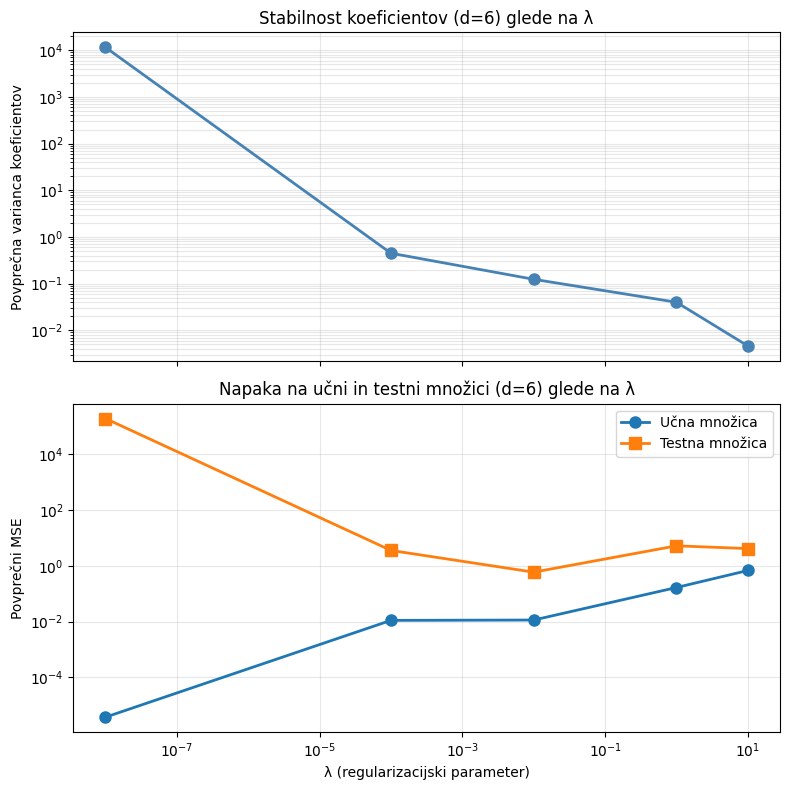


Optimalna vrednost λ za testni MSE: 1e-02


In [10]:
lambda_values = [1e-8, 1e-4, 1e-2, 1, 10]
d_fixed = 6

mean_variances = []
mean_train_mse = []
mean_test_mse = []

print(f'Rezultati za polinom stopnje d={d_fixed}:')
print(f'{"λ":>10}  {"Povpr. varianca":>18}  {"Povpr. MSE (učna)":>18}  {"Povpr. MSE (testna)":>20}')
print('-' * 72)

for lam in lambda_values:
    koeficienti = []
    train_mses = []
    test_mses = []

    for x, y in datasets:
        x_train = x[:5]
        y_train = y[:5]
        x_test = x[5:]
        y_test = y[5:]

        X_train = polinomske_znacilke(x_train, d_fixed)
        beta = najdi_koeficiente_reg(X_train, y_train, lambda_val=lam)
        koeficienti.append(beta)

        train_mses.append(mean_squared_error(y_train, napovej(X_train, beta)))
        test_mses.append(mean_squared_error(y_test, napovej(polinomske_znacilke(x_test, d_fixed), beta)))

    var_mean = np.var(np.array(koeficienti), axis=0).mean()
    mean_variances.append(var_mean)
    mean_train_mse.append(np.mean(train_mses))
    mean_test_mse.append(np.mean(test_mses))
    print(f'{lam:>10.0e}  {var_mean:>18.6f}  {np.mean(train_mses):>18.6f}  {np.mean(test_mses):>20.6f}')

# Grafa
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

ax1.plot(lambda_values, mean_variances, 'o-', color='steelblue', linewidth=2, markersize=8)
ax1.set_ylabel('Povprečna varianca koeficientov')
ax1.set_title(f'Stabilnost koeficientov (d={d_fixed}) glede na λ')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.grid(True, which='both', alpha=0.3)

ax2.plot(lambda_values, mean_train_mse, 'o-', color='tab:blue', linewidth=2, markersize=8, label='Učna množica')
ax2.plot(lambda_values, mean_test_mse, 's-', color='tab:orange', linewidth=2, markersize=8, label='Testna množica')
ax2.set_xlabel('λ (regularizacijski parameter)')
ax2.set_ylabel('Povprečni MSE')
ax2.set_title(f'Napaka na učni in testni množici (d={d_fixed}) glede na λ')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

best_lam = lambda_values[int(np.argmin(mean_test_mse))]
print(f'\nOptimalna vrednost λ za testni MSE: {best_lam:.0e}')

**Odgovori na vprašanja**

> _[Kako vrednost λ vpliva na stabilnost koeficientov?]_
- Vidimo, da se stabilnost koef izboljšuje (povpečna varianca se manjša) z večanjem vrednosti λ.
> _[Kako vrednost λ vpliva na napako na učni in testni množici?]_
- Z večanjem λ se učna napaka veča, testna pa manjša (v povprečju, saj padanje ni konstantno).
> _[Pri kateri vrednosti λ je testna napaka najmanjša? Ali se to ujema z območjem nizke variance?]_
- Testna napak je najmanjša  pri λ = 1e-02. Tu sicer je varianca nizak, ampak ni najmanjša možna.
> _[Ali obstaja kompromis med stabilnostjo in napako (točnostjo) polinomskega modela? Kaj se zgodi pri zelo majhnih in zelo velikih vrednostih λ?]_
-  V tem primeru bi razglasil λ = 1e-02 kot dober primer ravnotežja med stabilnostjo in napako polinomskega modela. Pri tej vrednosti je napaka na učni množici nekje na sredini v primerjavi z ostalimi vrednostmi, kar nam sporoča da ne prihaja do overfittinga na učni množici.
- Problem pri zelo majhni vrednosti lamda je, da se polinomski model preveč podobno obnaša kot, če nebi izvedli regularizacije koeficientov. Že v prejšnji nalogah smo videli, da se polinsmiki modeli visokih stopenj pre dobro naučijo učne podatke in potem slabo generalizirajo na novih (overfitting). Tako je sedaj s tem modelom pri nizki vrednsoti lamde. Pre dobro se nauči učnih podatkov, zato je učna napaka nizka in varianca koef visoka po drugi starni pa je testna napaka visoka.
- Če je pri nizki vrednosti lamde bil problem overfitting je pri visoki problem underfittg. Varianca koef je zelo nizka (približuje se nič), učna napaka pa precej visoka. Model se pre slabo nauči učne podatke in je zato preveč preprost. Posledično se tudi testna napaka model poveča pri največjih vrednostih lamde (1 in 10) v primerjavi z najboljšo vrednsotjo λ = 1e-02. Je pa vredno omeniti, da je testna napaka vseesno veliko manjša kot za najmanjšo vrednost λ.




## Naloga 2 (10 točk): Klasifikacija tumorjev dojke

Analiziraj podatke iz datoteke `dn1_e2.npz` in sestavi napovedni model, ki bo čim boljše napovedal, ali je tumor maligni ali benigni. Poskrbi, da poleg ocene zmogljivosti modela poročaš tudi o **stabilnosti ocene njegove zmogljivosti** (npr. s prečnim preverjanjem). Opiši tvoj izbrani model ter kako in zakaj si se odločal/a pri vsakem vidiku njegove izbire. Opiši tudi ostale modele, ki si jih poskusil/a, a jih nisi izbral/a, ker niso dosegali zmogljivosti izbranega modela.

Lahko izbiraš med linearnimi modeli, modeli najbližjih sosedov in odločitvenimi drevesi. Kot mero zmogljivosti lahko uporabiš poljubno mero za zmogljivost modelov za binarno (dvojiško) klasifikacijo, ki smo jih obravnavali na predavanjih in vajah. Obrazloži svojo izbiro mere zmogljivosti na osnovi katere boš izbiral/a najboljši model.

Podatkovna množica vsebuje 569 primerov in 30 napovednih spremenljivk, pridobljenih iz slik celic tumorja. Pomen napovednih spremenljivk je sledeč (vsaka od desetih osnovnih mer naštetih pod tabelo je podana s tremi spremenljivkami, povprečje, standardna napaka in najslabša vrednost):

| Indeks | Agregatna funkcija | Opis |
|--------|----------|------|
| 0–9 | Povprečje | Povprečna vrednost mere čez jedra v primeru |
| 10–19 | Standardna napaka | Standardna napaka mere |
| 20–29 | Najslabša vrednost | Povprečje treh največjih vrednosti mere |

Deset osnovnih mer: polmer jedra, tekstura, obseg, površina, gladkost, kompaktnost, konkavnost, konkavne točke, simetrija in fraktalna dimenzija.

In še pomen vrednosti ciljne spremenljivke je:
- $y = 0$: maligni tumor in
- $y = 1$: benigni tumor.

**Opis modela in odločitev:**  
Moja izbira za najboljši napovedni model je **kNN s parametrom k=2**. V nadeljevanju je opisano 
in prikazano vso moje raziskovanje modelov in njihovih parametrov.


### Pregled podatkov

In [11]:
# Naložimo podatke
data = np.load("dn1_e2.npz")
print(data)

# Napovedne značilke in ciljne spremenljivke
X = data["X"]
y = data["y"]

# Poglejmo si koliko ciljnih sprem. je malignih in koliko benignih tumorjev
st_malignih = 0
st_benignih = 0
for i in y:
    if i == 0:
        st_malignih += 1
    else:
        st_benignih += 1
print(f"\nŠtevilo malignih tumorjev: {st_malignih} ~ {round((st_malignih/len(y) * 100))}%")
print(f"Število benignih tumorjev: {st_benignih} ~ {round((st_benignih/len(y) * 100))}%")

# Zaloge vrednosti značilk
print("\nZaloge vrednosti značilk:")
print("Min vrednosti:", X.min(axis=0))
print("Max vrednosti:", X.max(axis=0))

NpzFile 'dn1_e2.npz' with keys: X, y, feature_names, target_names

Število malignih tumorjev: 212 ~ 37%
Število benignih tumorjev: 357 ~ 63%

Zaloge vrednosti značilk:
Min vrednosti: [6.981e+00 9.710e+00 4.379e+01 1.435e+02 5.263e-02 1.938e-02 0.000e+00
 0.000e+00 1.060e-01 4.996e-02 1.115e-01 3.602e-01 7.570e-01 6.802e+00
 1.713e-03 2.252e-03 0.000e+00 0.000e+00 7.882e-03 8.948e-04 7.930e+00
 1.202e+01 5.041e+01 1.852e+02 7.117e-02 2.729e-02 0.000e+00 0.000e+00
 1.565e-01 5.504e-02]
Max vrednosti: [2.811e+01 3.928e+01 1.885e+02 2.501e+03 1.634e-01 3.454e-01 4.268e-01
 2.012e-01 3.040e-01 9.744e-02 2.873e+00 4.885e+00 2.198e+01 5.422e+02
 3.113e-02 1.354e-01 3.960e-01 5.279e-02 7.895e-02 2.984e-02 3.604e+01
 4.954e+01 2.512e+02 4.254e+03 2.226e-01 1.058e+00 1.252e+00 2.910e-01
 6.638e-01 2.075e-01]


### Pojasnilo nekaterih mojih odločitev

Zgoraj vidimo, da je zaloga vrednosti različnih značilk različna, zato sem normaliziral podatke pri modelu kNN z funckijo StandardScaler.

Preizkusil sem tri modele; logistično regresijo, kNN in odločitveno drevo.

Kot glavno mero zmoglivosti sem uporabil Priklic (Recall), saj če bi tumor napačno
klasificirali kot benigni, ko je pravzaprav maligni, bi to bilo zelo slabo za bolnika
in ravno Priklic nam pomaga oceniti, če smo našli čim več pozitivnih primerov. Ker pa smo maligne tumorje definirali kot y = 0 in benigne kot y = 1, sem v recall_score nastavil parameter pos_label=0. S tem bo Priklic meril kako dobro modeli najdejo maligne tumorje.  
Kot sekundarno mero zmoglivosti sem uporabil F1 score, kje sem pos_lable tudi nastavil na 0.

### Logistična regresija

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.metrics import recall_score, f1_score

np.random.seed(4)

kfold = KFold(n_splits=5, shuffle=True, random_state=4)

priklic = []
f1 = []
for i, (train_index, test_index) in enumerate(kfold.split(X, y)):
    # Učna množica
    X_train = X[train_index, :]
    y_train = y[train_index]
    # Testna množica
    X_test = X[test_index, :]
    y_test = y[test_index]
    
    # Model
    model = LogisticRegression(max_iter=4000).fit(X_train, y_train) 
    y_pred = model.predict(X_test)

    # Priklic in F1
    priklic_fold = recall_score(y_test, y_pred, pos_label=0)
    f1_fold = f1_score(y_test, y_pred, pos_label=0)

    priklic.append(priklic_fold)
    f1.append(f1_fold)

    print(f"Fold {i}: Priklic {priklic_fold}\n"
          f"        F1 score {f1_fold}")

# Povprečna vrednost mer zmoglivosti in njihova varianca
print(f"\nPovprečen Priklic: {np.mean(priklic)}")
print(f"Varianca Priklica: {np.var(priklic)}")
print(f"Povprečen F1: {np.mean(f1)}")
print(f"Varianca F1 score: {np.var(f1)}")

# Komentar: v LogisticRegression() sem nastavil max_iter=4000, ker brez tega
# mi Python vrne komentar "STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT..." in
# me prosi naj povečam število iteracij, da bo potem bolje konvergiral.

# Shranimo Priklic za logistično regresijo
priklic_log_reg = np.mean(priklic)


Fold 0: Priklic 0.9411764705882353
        F1 score 0.8648648648648649
Fold 1: Priklic 0.9
        F1 score 0.9113924050632911
Fold 2: Priklic 0.9523809523809523
        F1 score 0.963855421686747
Fold 3: Priklic 0.8888888888888888
        F1 score 0.9195402298850575
Fold 4: Priklic 0.8823529411764706
        F1 score 0.9375

Povprečen Priklic: 0.9129598506069094
Varianca Priklica: 0.0008068705477833832
Povprečen F1: 0.919430584299992
Varianca F1 score: 0.0010684224091295955


### K-najbližjih sosedov

Da bi bil model kNN, čim boljši sem poiskusil različne vrednosti parametra k
in med njimi primerjal mero Priklic in F1. Ker imajo značilke različne
zaloge vrednosti (na kar je model kNN zelo občutliv), sem normaliziral podatke.

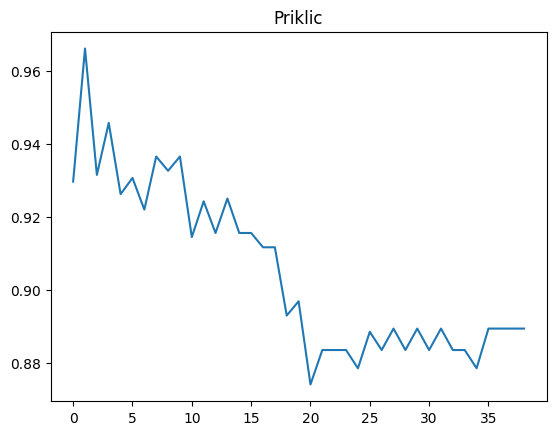

Najboljši k za Priklic je 2 z vrednostjo 0.9662184873949581


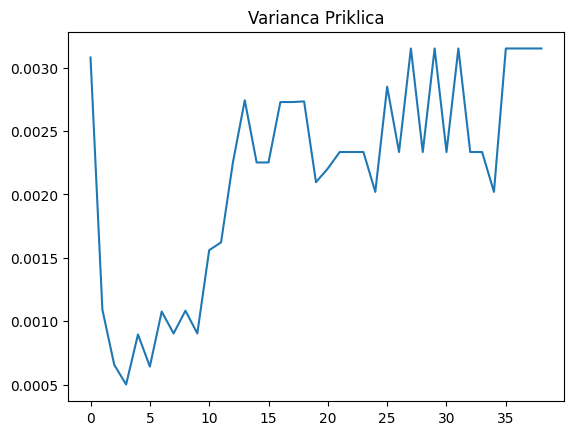

Najnižja varianca Priklica je pri k = 4 z vrednostjo 0.0005012993432667184.
Pri k = 2 je varianca enaka 0.0010913730197961544.


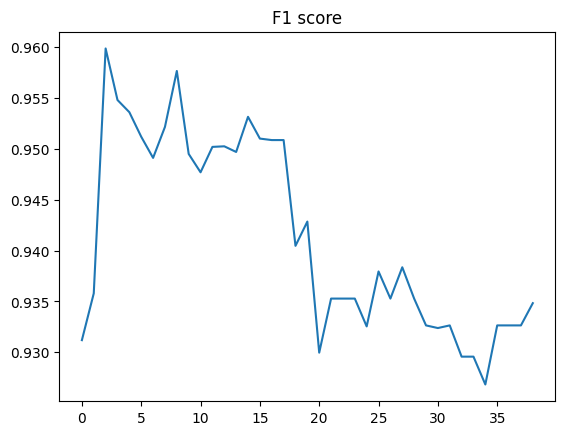

Najboljši k za F1 je 3 z vrednostjo 0.9598481195847194


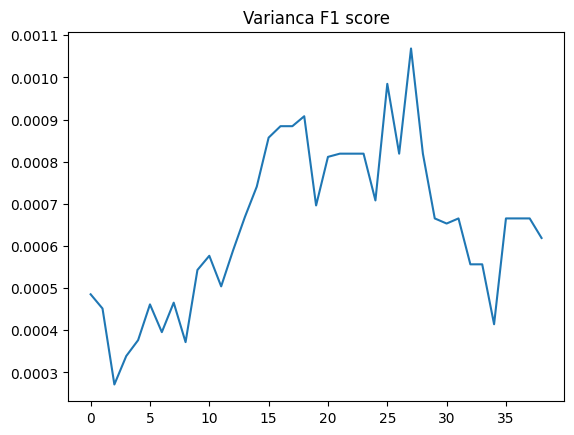

Najnižja varianca F1 score je pri k = 3 z vrednostjo 0.0002714299189226577.
Pri k = 3 je varianca enaka 0.0002714299189226577.


In [13]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


kfold = KFold(n_splits=5, shuffle=True, random_state=4)
priklic = []
f1 = []
var_priklic = []
var_f1 = []

for n_neighbours in range(1, 40):
    folds_priklic = []
    folds_f1 = []

    for i, (train_index, test_index) in enumerate(kfold.split(X)):
        # Učna množica
        X_train = X[train_index]
        y_train = y[train_index]
        # Testna množica
        X_test = X[test_index]
        y_test = y[test_index]
        
        # Normalizacija
        norm = StandardScaler()
        X_train_norm = norm.fit_transform(X_train)
        X_test_norm = norm.transform(X_test)

        # Model
        model = KNeighborsClassifier(n_neighbors=n_neighbours).fit(X_train_norm, y_train)
        y_pred = model.predict(X_test_norm)

        # Priklic in F1
        folds_priklic.append(recall_score(y_test, y_pred, pos_label=0))
        folds_f1.append(f1_score(y_test, y_pred, pos_label=0))

    
    priklic.append(np.mean(folds_priklic))
    f1.append(np.mean(folds_f1))
    # Varianca
    var_priklic.append(np.var(folds_priklic))
    var_f1.append(np.var(folds_f1))


plt.plot(priklic)
plt.title("Priklic")
plt.show()
print(f"Najboljši k za Priklic je {np.argmax(priklic)+1} z vrednostjo {np.max(priklic)}")

plt.plot(var_priklic)
plt.title("Varianca Priklica")
plt.show()
print(f"Najnižja varianca Priklica je pri k = {np.argmin(var_priklic) + 1} z vrednostjo {np.min(var_priklic)}."
      f"\nPri k = {np.argmax(priklic)+1} je varianca enaka {var_priklic[np.argmax(priklic)]}.")

plt.plot(f1)
plt.title("F1 score")
plt.show()
print(f"Najboljši k za F1 je {np.argmax(f1)+1} z vrednostjo {np.max(f1)}")

plt.plot(var_f1)
plt.title("Varianca F1 score")
plt.show()
print(f"Najnižja varianca F1 score je pri k = {np.argmin(var_f1) + 1} z vrednostjo {np.min(var_f1)}."
      f"\nPri k = {np.argmax(f1)+1} je varianca enaka {var_f1[np.argmax(f1)]}.")


# Shranimo Priklic za kNN s k=2
priklic_knn = priklic[1]

**Moja izbira za parameter k pri modelu kNN:**  
Kot najboljši k za model kNN sem izbral **k = 2**. Pri tem k ima model najvišjo vrednost
Priklica in nizko varianco 0.0010913730197961544. Kjub temu, da to ni najnižja možna
varianca, je še vedno dovolj nizka, da lahko model razglasimo kot stabilnega.  
V veliko primerih lahko nizka vrednsot za k vodi do overfitting-a. Po mojem mnenju
v tem primeru to ne drži, saj sem Priklic in F1 računal na testnih podatkih.

### Odločitveno drevo

Kot zadnji model sem si pogledal odločitveno drevo. S sprotnim rezanjem sem probal preprečiti overfitting in izračunal Priklica ter F1 za različne vrednosti parametra min_sample_split. 

Ustavi rezanje, ko je največ 2 primerov v listih. Priklic: 0.9021055088702148.
Ustavi rezanje, ko je največ 3 primerov v listih. Priklic: 0.9071055088702146.
Ustavi rezanje, ko je največ 4 primerov v listih. Priklic: 0.9118674136321196.
Ustavi rezanje, ko je največ 5 primerov v listih. Priklic: 0.9118674136321196.
Ustavi rezanje, ko je največ 10 primerov v listih. Priklic: 0.9079458450046687.
Ustavi rezanje, ko je največ 20 primerov v listih. Priklic: 0.8981839402427638.
Ustavi rezanje, ko je največ 50 primerov v listih. Priklic: 0.9011111111111111.


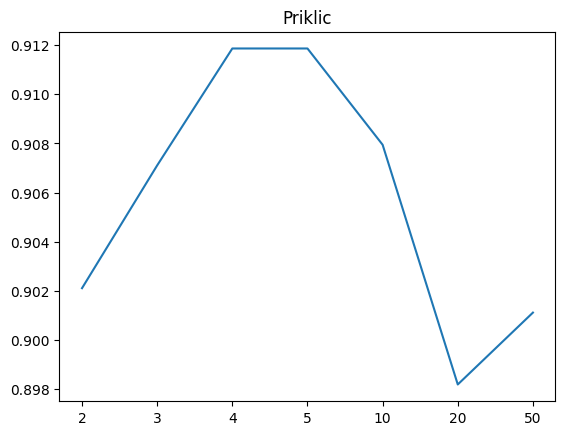

Najboljši min_samples_split za Priklic je 4 z vrednostjo 0.9118674136321196


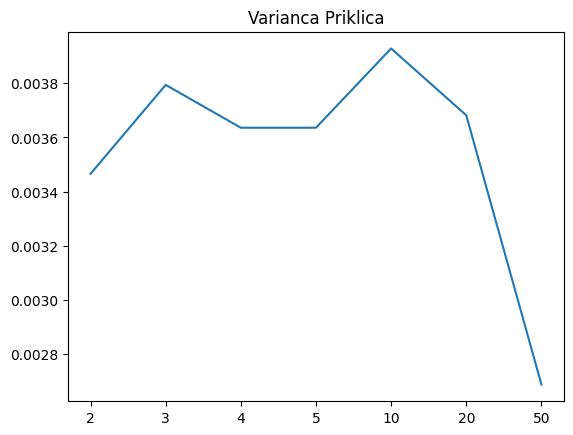

Najnižja varianca Priklica je pri min_samples_split = 50 z vrednostjo 0.002686471015421417.
Pri min_samples_split = 4 je varianca enaka 0.0036358599213105725.


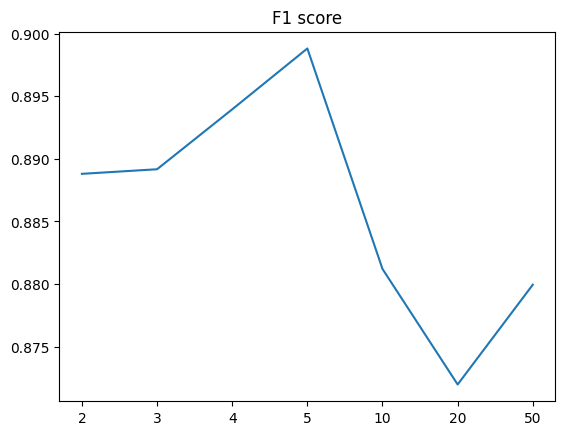

Najboljši min_samples_split za F1 je 5 z vrednostjo 0.898818704329368


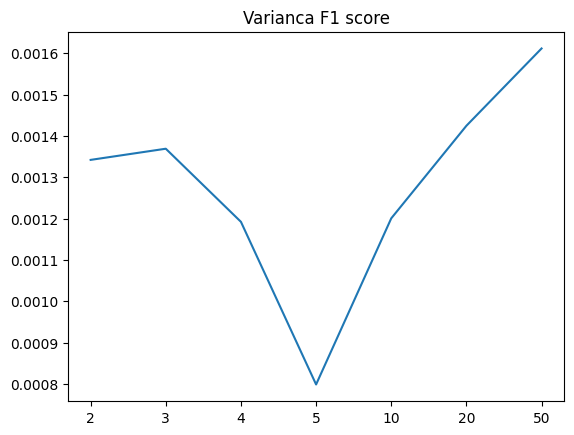

Najnižja varianca F1 score je pri min_samples_split = 5 z vrednostjo 0.0007985568743616542.
Pri min_samples_split = 5 je varianca enaka 0.0007985568743616542.


In [14]:
from sklearn.tree import DecisionTreeClassifier

priklic = []
f1 = []
var_priklic = []
var_f1 = []

for num_min_instances in [2, 3, 4, 5, 10, 20, 50]:
    folds_priklic = []
    folds_f1 = []
    np.random.seed(4)
    kfold = KFold(n_splits=5, shuffle=True, random_state=4)
    
    for i, (train_index, test_index) in enumerate(kfold.split(X)):
        # Učna množica 
        x_train = X[train_index]
        y_train = y[train_index]
        # Testna množica
        x_test = X[test_index]
        y_test = y[test_index]
        # Model
        model = DecisionTreeClassifier(min_samples_split=num_min_instances).fit(x_train, y_train)
        y_pred = model.predict(x_test)

        folds_priklic.append(recall_score(y_test, y_pred, pos_label=0))
        folds_f1.append(f1_score(y_test, y_pred, pos_label=0))

    print(f"Ustavi rezanje, ko je največ {num_min_instances} primerov v listih. Priklic: {np.mean(folds_priklic)}.")
    priklic.append(np.mean(folds_priklic))
    f1.append(np.mean(folds_f1))
    # Varianca
    var_priklic.append(np.var(folds_priklic))
    var_f1.append(np.var(folds_f1))


plt.plot(priklic)
plt.xticks(list(range(7)),labels=[2, 3, 4, 5, 10, 20, 50])
plt.title("Priklic")
plt.show()
print(f"Najboljši min_samples_split za Priklic je {[2, 3, 4, 5, 10, 20, 50][np.argmax(priklic)]} z vrednostjo {np.max(priklic)}")

plt.plot(var_priklic)
plt.xticks(list(range(7)),labels=[2, 3, 4, 5, 10, 20, 50])
plt.title("Varianca Priklica")
plt.show()
print(f"Najnižja varianca Priklica je pri min_samples_split = {[2, 3, 4, 5, 10, 20, 50][np.argmin(var_priklic)]} z vrednostjo {np.min(var_priklic)}."
      f"\nPri min_samples_split = {[2, 3, 4, 5, 10, 20, 50][np.argmax(priklic)]} je varianca enaka {var_priklic[np.argmax(priklic)]}.")

plt.plot(f1)
plt.xticks(list(range(7)),labels=[2, 3, 4, 5, 10, 20, 50])
plt.title("F1 score")
plt.show()
print(f"Najboljši min_samples_split za F1 je {[2, 3, 4, 5, 10, 20, 50][np.argmax(f1)]} z vrednostjo {np.max(f1)}")

plt.plot(var_f1)
plt.xticks(list(range(7)),labels=[2, 3, 4, 5, 10, 20, 50])
plt.title("Varianca F1 score")
plt.show()
print(f"Najnižja varianca F1 score je pri min_samples_split = {[2, 3, 4, 5, 10, 20, 50][np.argmin(var_f1)]} z vrednostjo {np.min(var_f1)}."
      f"\nPri min_samples_split = {[2, 3, 4, 5, 10, 20, 50][np.argmax(f1)]} je varianca enaka {var_f1[np.argmax(f1)]}.")

# Shranimo Priklic za odločitveno drevo s min_samples_split=4
priklic_odl_drevo = priklic[2]

**Moja izbira parametra min_sample_split pri modelu odločitveno drevo:**  
Za parameter min_sample_split sem izbral 4, ker je pri tej vrednosti Prilkic najvišji. Hkrati je tudi varianca nizka z vrednostjo 0.0036358599213105725, kar potrjuje stabilnost modela.

### Primerjava modelov in izbira najboljšega
Pri tej točki sem že našel najboljše parametre za vse modele. V nadeljevanju je 
kratka primerjava model in moja izbira najboljšega.


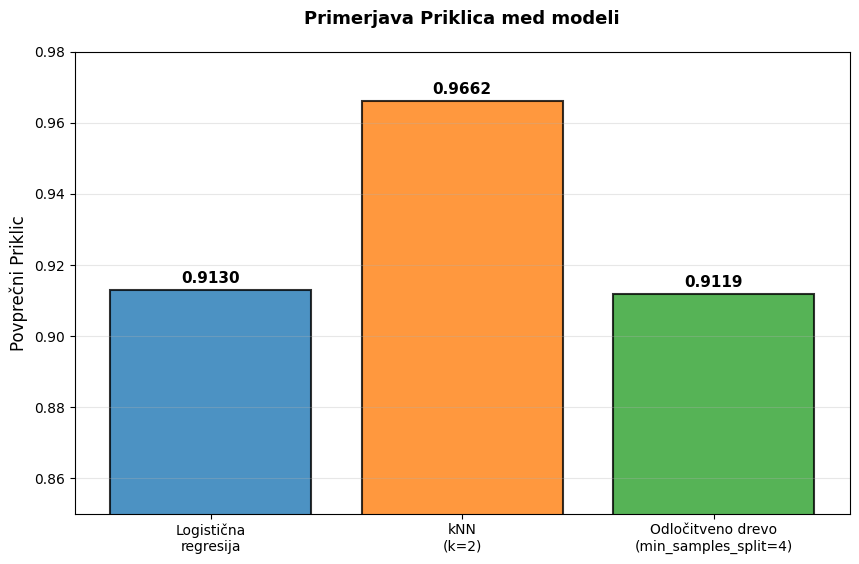

In [15]:
modeli = ['Logistična\nregresija', 'kNN\n(k=2)', 'Odločitveno drevo\n(min_samples_split=4)']
vrednosti_priklica = [priklic_log_reg, priklic_knn, priklic_odl_drevo]
barve = ['#1f77b4', '#ff7f0e', '#2ca02c']

plt.figure(figsize=(10, 6))
stolpci = plt.bar(modeli, vrednosti_priklica, color=barve, alpha=0.8, edgecolor='black', linewidth=1.5)

# Vrednosti damo na vrh stolpcev
for stolpec, vrednost in zip(stolpci, vrednosti_priklica):
    plt.text(stolpec.get_x() + stolpec.get_width()/2, stolpec.get_height() + 0.001, 
             f'{vrednost:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylabel('Povprečni Priklic', fontsize=12)
plt.title('Primerjava Priklica med modeli', fontsize=13, fontweight='bold', pad=20)
plt.ylim([0.85, 0.98])
plt.grid(axis='y', alpha=0.3)
plt.show()


Glede na mero Priklic je model kNN (k=2) najboljši, zato ga izbiram.  
Vredno je omeniti, da sta tudi logistična regresija in odločitveno drevo dosegla zelo dobre rezultate, vendar je rezultat modela kNN dovolj bolj zmogljiv, da ostalih dveh ne bi izbral.